In [9]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [11]:
# Load the data
df = pd.read_csv('titanic.csv')

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (891, 12)

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [14]:
df_clean = df.copy()

df_clean['Age'] = df_clean.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

df_clean['Deck'] = df_clean['Cabin'].str[0]
df_clean['Has_Cabin'] = df_clean['Cabin'].notna().astype(int)

df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

df_clean['Family_Size'] = df_clean['SibSp'] + df_clean['Parch']
df_clean['Is_Alone'] = (df_clean['Family_Size'] == 0).astype(int)

df_clean['Title'] = df_clean['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

bins = [0, 12, 18, 30, 50, 100]
labels = ['Child (0-12)', 'Teen (13-18)', 'Young Adult (19-30)', 
          'Middle Age (31-50)', 'Senior (50+)']
df_clean['Age_Group'] = pd.cut(df_clean['Age'], bins=bins, labels=labels)

print("Missing values after cleaning:")
print(df_clean.isnull().sum())
print(f"\nDataset shape: {df_clean.shape}")
print(f"Overall Survival Rate: {df_clean['Survived'].mean()*100:.1f}%")

Missing values after cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
Deck           687
Has_Cabin        0
Family_Size      0
Is_Alone         0
Title            0
Age_Group        0
dtype: int64

Dataset shape: (891, 18)
Overall Survival Rate: 38.4%


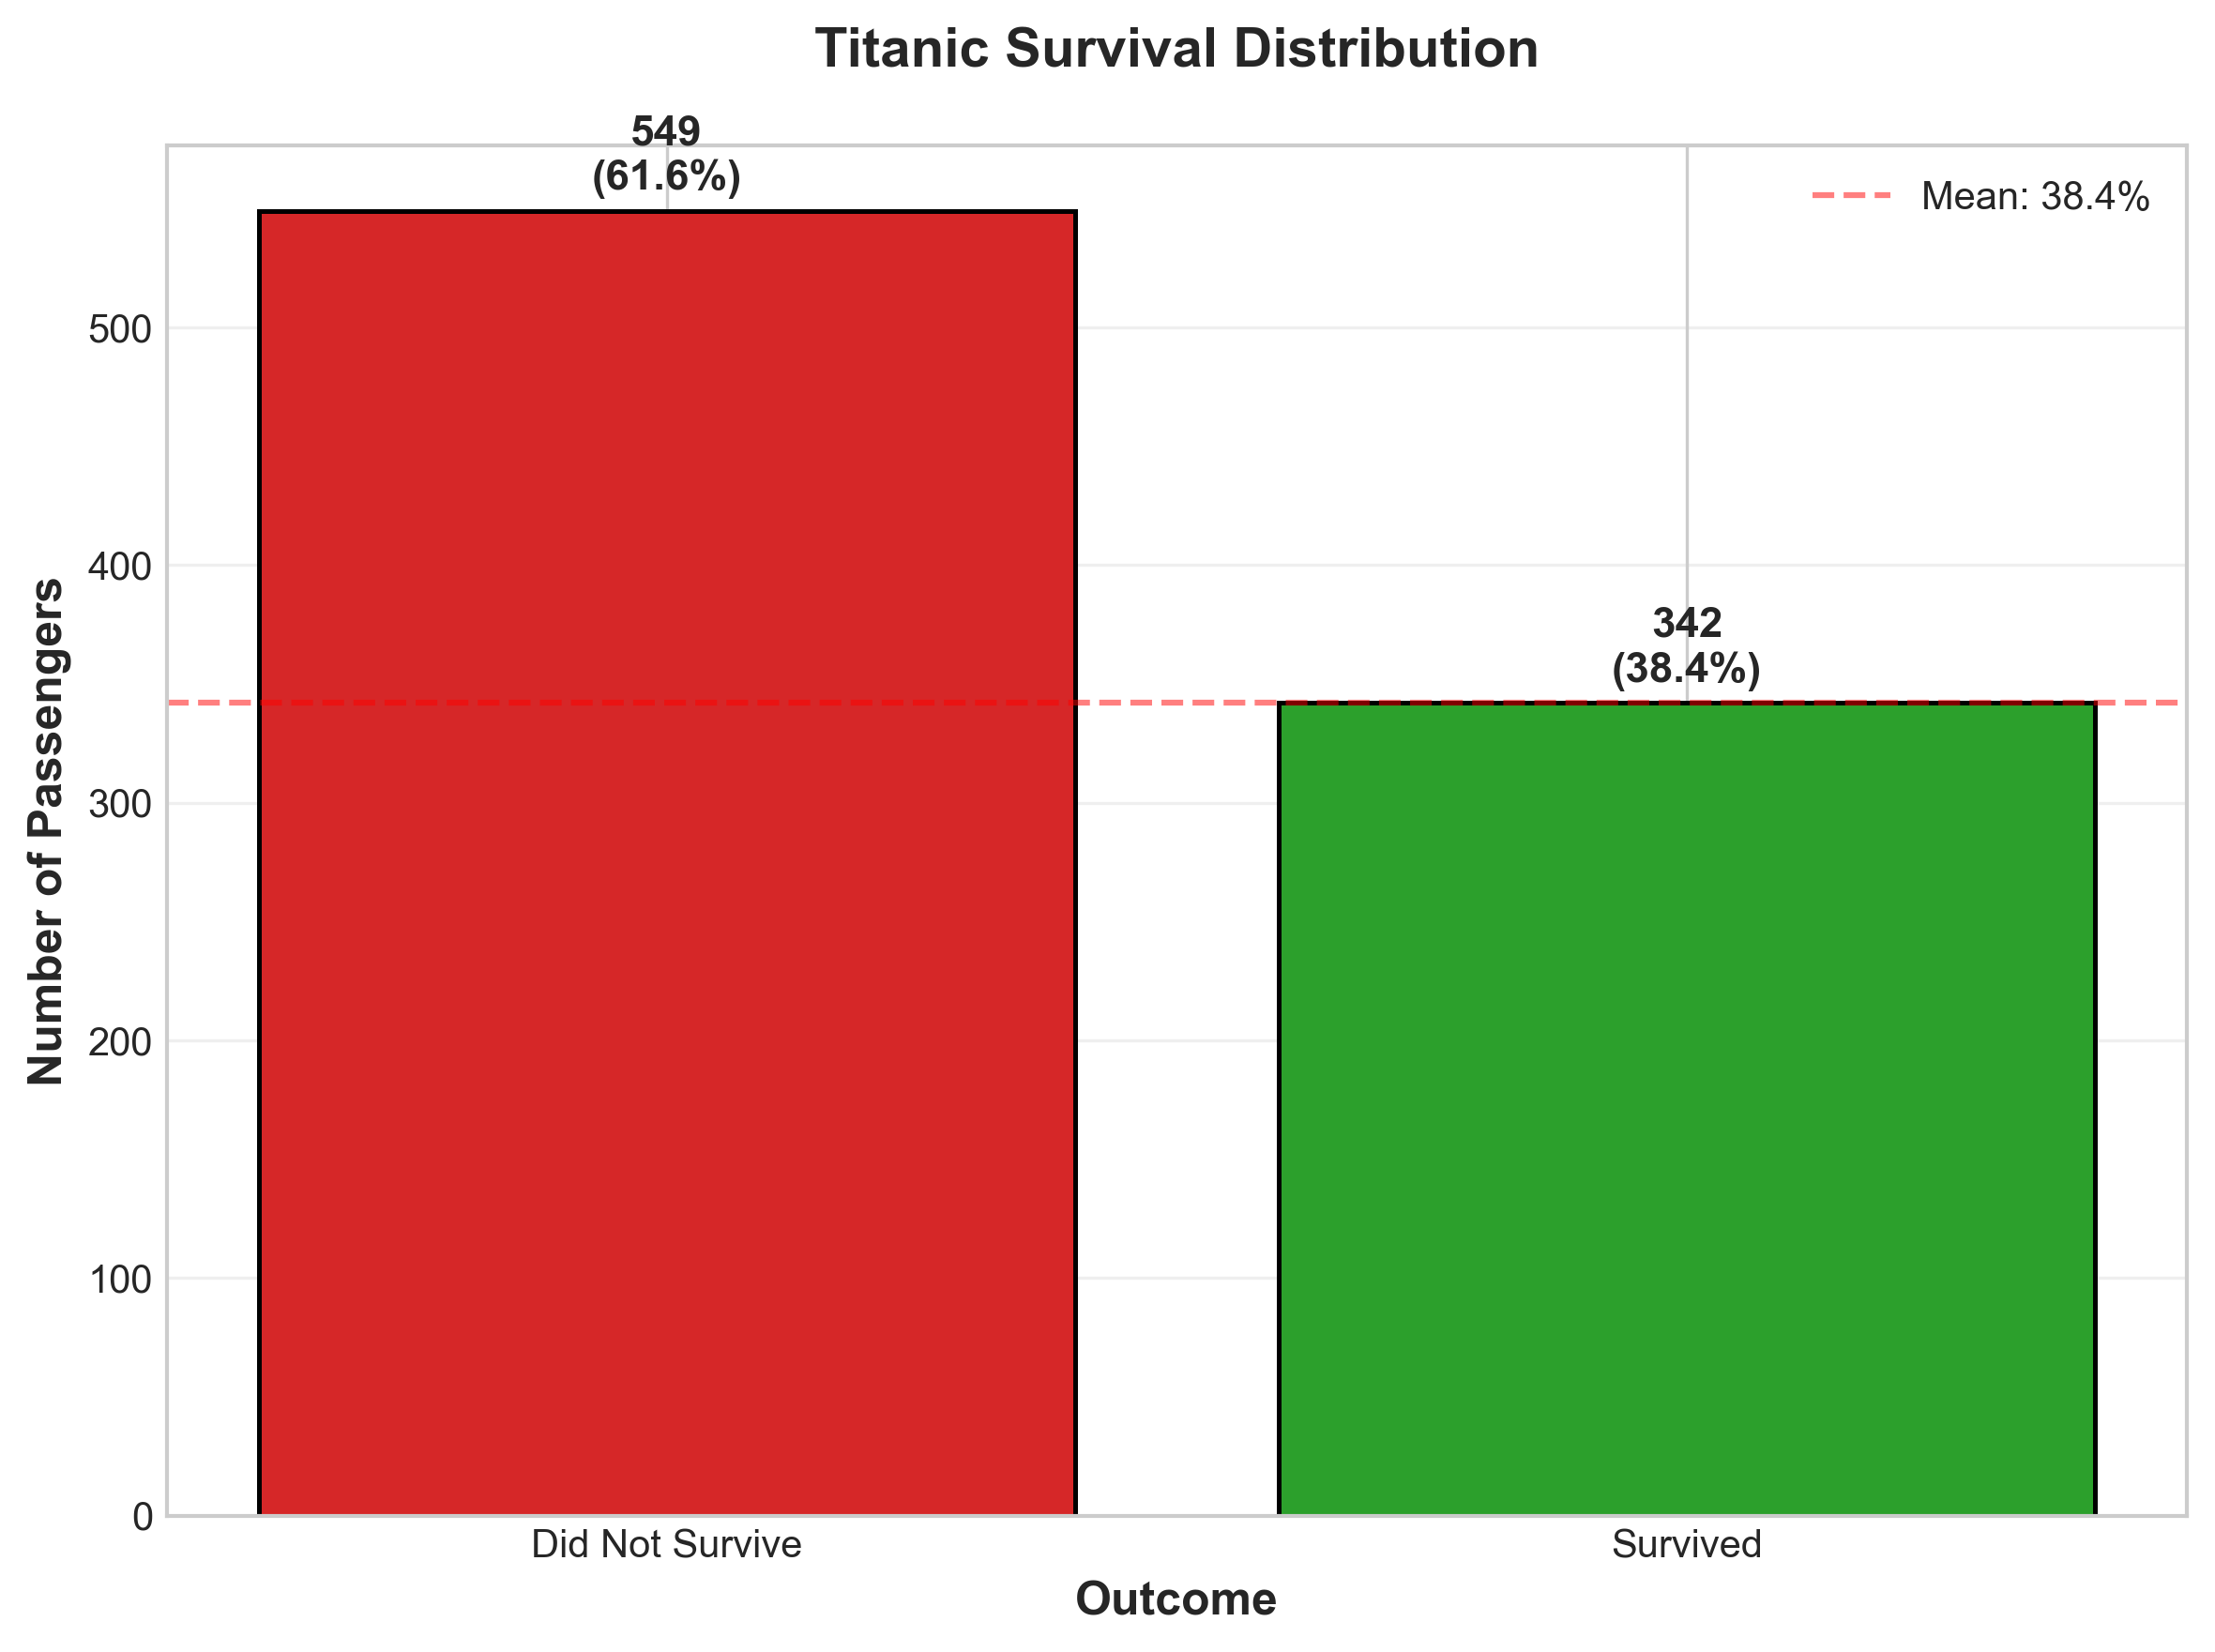

In [5]:
# Chart 1: Overall Survival Distribution
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#d62728', '#2ca02c']
survival_counts = df_clean['Survived'].value_counts().sort_index()
bars = ax.bar(['Did Not Survive', 'Survived'], 
              survival_counts,
              color=colors, edgecolor='black', linewidth=1.2)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 5,
            f'{int(height)}\n({height/len(df_clean)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('Outcome', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Passengers', fontsize=12, fontweight='bold')
ax.set_title('Titanic Survival Distribution', fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3)

mean_survival = df_clean['Survived'].mean() * len(df_clean)
ax.axhline(y=mean_survival, color='red', linestyle='--', alpha=0.5, 
           label=f'Mean: {df_clean["Survived"].mean()*100:.1f}%')
ax.legend()

plt.tight_layout()
plt.show()

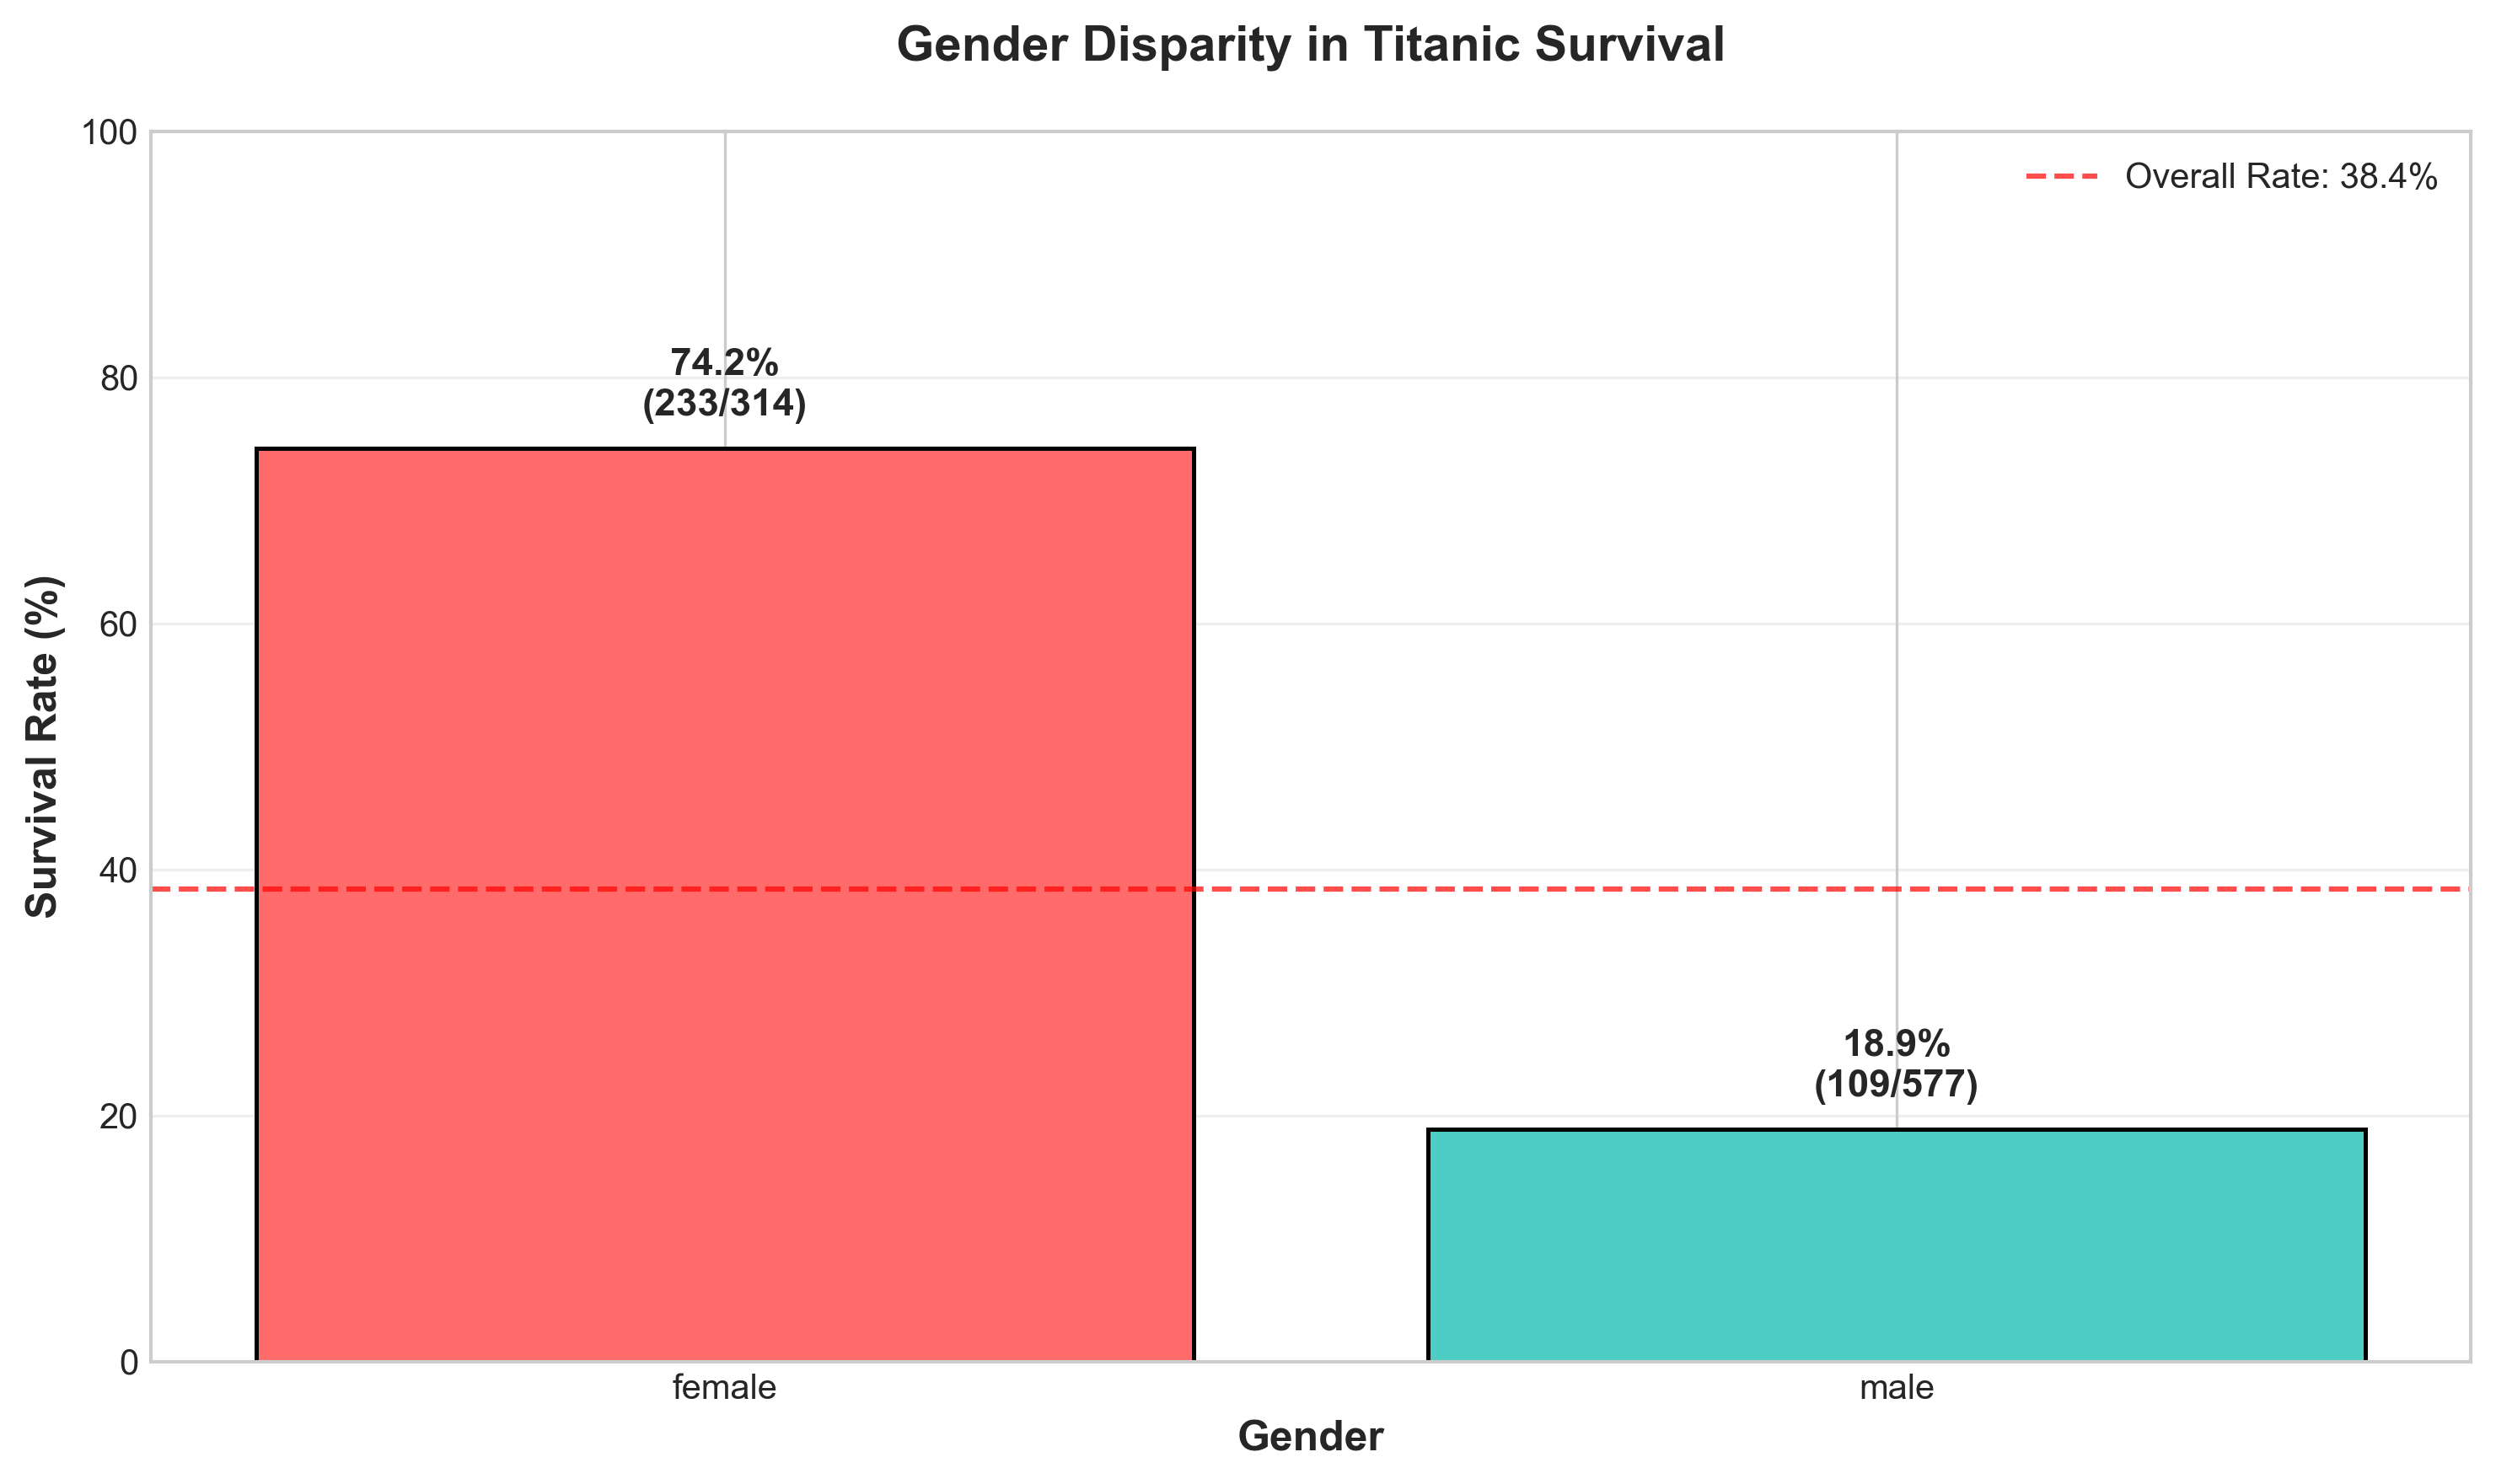

In [15]:
# Chart 2: Gender Disparity in Survival
fig, ax = plt.subplots(figsize=(10, 6))

survival_by_sex = df_clean.groupby('Sex')['Survived'].mean() * 100

bars = ax.bar(survival_by_sex.index, survival_by_sex.values,
              color=['#ff6b6b', '#4ecdc4'], edgecolor='black', linewidth=1.2)

for i, (bar, sex) in enumerate(zip(bars, survival_by_sex.index)):
    count = len(df_clean[df_clean['Sex'] == sex])
    survived = len(df_clean[(df_clean['Sex'] == sex) & (df_clean['Survived'] == 1)])
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 2,
            f'{height:.1f}%\n({survived}/{count})',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_xlabel('Gender', fontsize=12, fontweight='bold')
ax.set_ylabel('Survival Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('Gender Disparity in Titanic Survival', fontsize=14, fontweight='bold', pad=20)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

overall = df_clean['Survived'].mean() * 100
ax.axhline(y=overall, color='red', linestyle='--', alpha=0.7,
           label=f'Overall Rate: {overall:.1f}%')
ax.legend()

plt.tight_layout()
plt.show()

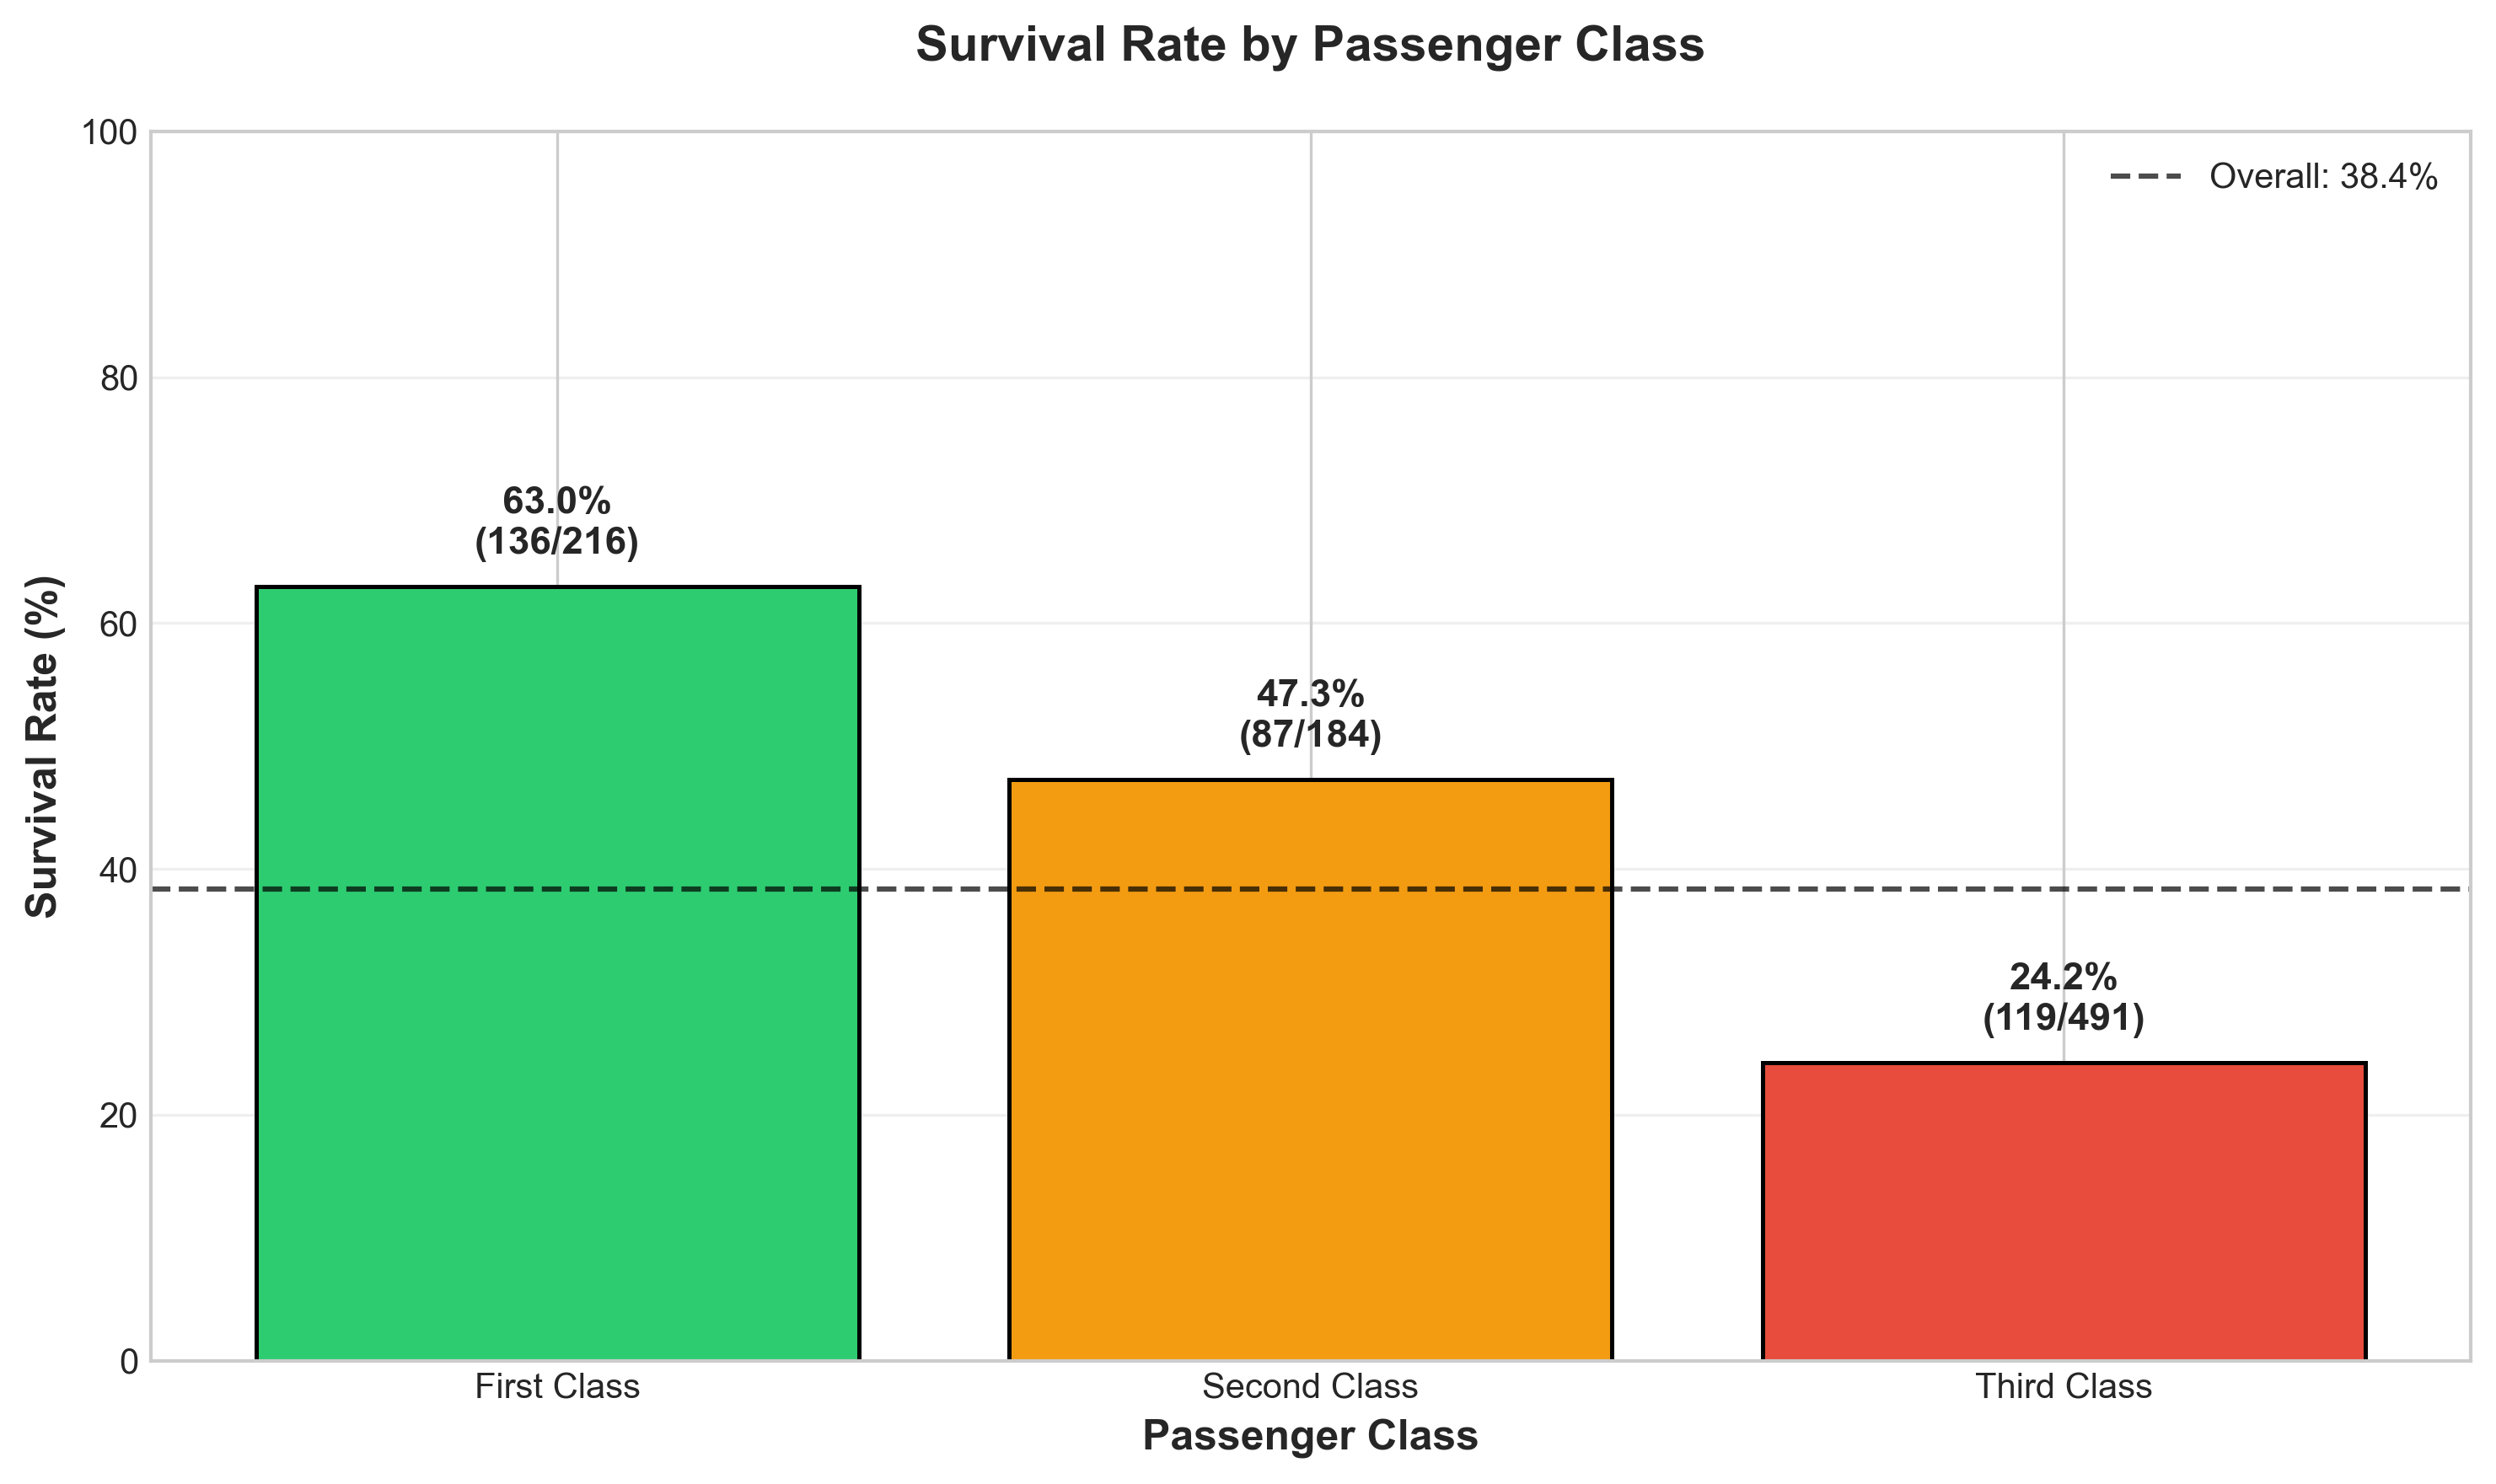

In [7]:
# Chart 3: Survival by Passenger Class
fig, ax = plt.subplots(figsize=(10, 6))

survival_by_class = df_clean.groupby('Pclass')['Survived'].mean() * 100
class_counts = df_clean['Pclass'].value_counts().sort_index()

colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = ax.bar(['First Class', 'Second Class', 'Third Class'], 
              survival_by_class.values,
              color=colors, edgecolor='black', linewidth=1.2)

for i, (bar, pclass) in enumerate(zip(bars, survival_by_class.index)):
    count = class_counts[pclass]
    survived = len(df_clean[(df_clean['Pclass'] == pclass) & (df_clean['Survived'] == 1)])
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 2,
            f'{height:.1f}%\n({survived}/{count})',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_xlabel('Passenger Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Survival Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('Survival Rate by Passenger Class', fontsize=14, fontweight='bold', pad=20)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

overall = df_clean['Survived'].mean() * 100
ax.axhline(y=overall, color='black', linestyle='--', alpha=0.7,
           label=f'Overall: {overall:.1f}%')
ax.legend()

plt.tight_layout()
plt.show()

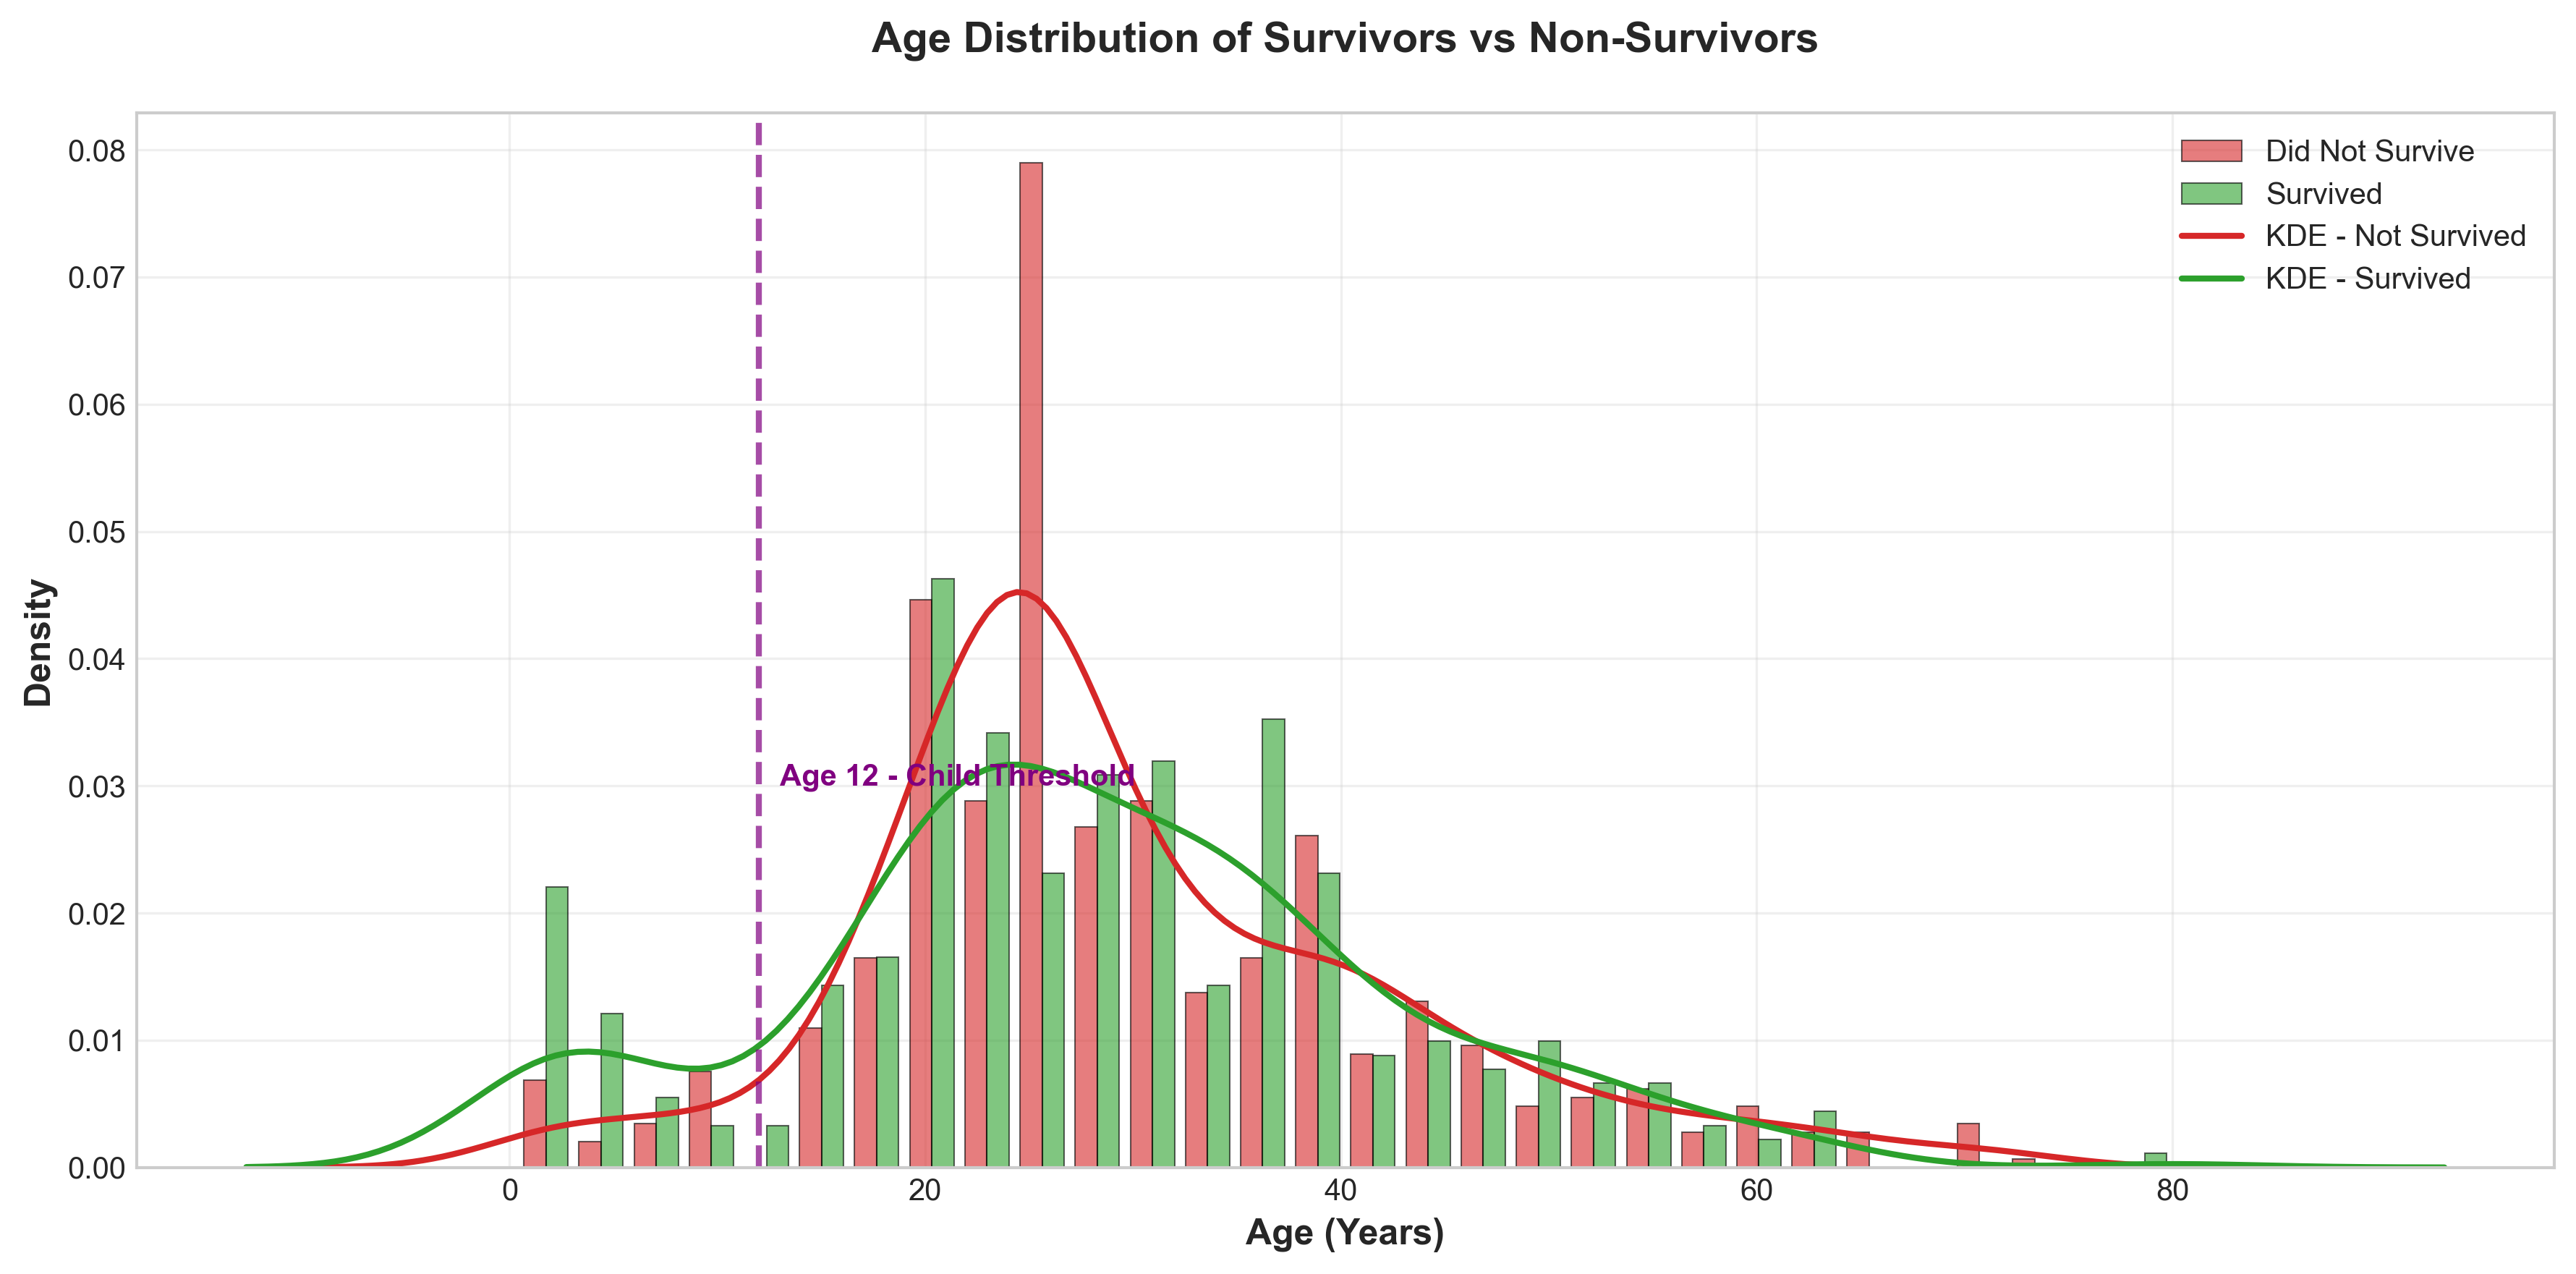

In [16]:
# Chart 4: Age Distribution with Survival Overlay
fig, ax = plt.subplots(figsize=(12, 6))

survived = df_clean[df_clean['Survived'] == 1]['Age']
not_survived = df_clean[df_clean['Survived'] == 0]['Age']

ax.hist([not_survived, survived], bins=30, alpha=0.6, 
        color=['#d62728', '#2ca02c'], 
        label=['Did Not Survive', 'Survived'],
        edgecolor='black', linewidth=0.5, density=True)

sns.kdeplot(data=not_survived, color='#d62728', linewidth=2, label='KDE - Not Survived', ax=ax)
sns.kdeplot(data=survived, color='#2ca02c', linewidth=2, label='KDE - Survived', ax=ax)

ax.set_xlabel('Age (Years)', fontsize=12, fontweight='bold')
ax.set_ylabel('Density', fontsize=12, fontweight='bold')
ax.set_title('Age Distribution of Survivors vs Non-Survivors', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right')
ax.grid(alpha=0.3)

ax.axvline(x=12, color='purple', linestyle='--', alpha=0.7, linewidth=2)
ax.text(13, 0.03, 'Age 12 - Child Threshold', fontsize=10, fontweight='bold', color='purple')

plt.tight_layout()
plt.show()

Survival by Age Group (%):
Age_Group
0-10     59.4
11-20    38.3
21-30    32.4
31-40    44.9
41-50    38.4
51-60    40.5
60+      22.7
Name: Survived, dtype: float64


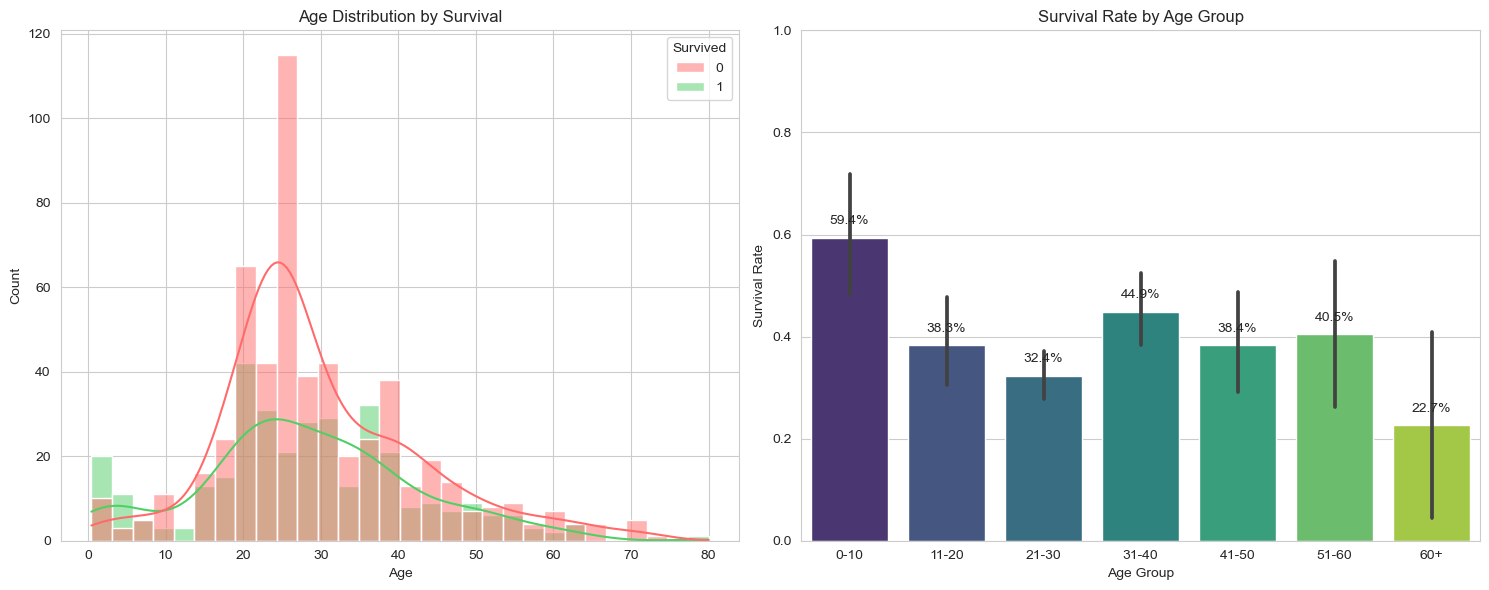

In [8]:
bins = [0, 10, 20, 30, 40, 50, 60, 100]
labels = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '60+']
df_clean['Age_Group'] = pd.cut(df_clean['Age'], bins=bins, labels=labels)

age_survival = df_clean.groupby('Age_Group')['Survived'].mean().round(3) * 100
print("Survival by Age Group (%):")
print(age_survival)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(data=df_clean, x='Age', hue='Survived', bins=30,
             kde=True, palette=['#ff6b6b', '#51cf66'], ax=axes[0])
axes[0].set_title('Age Distribution by Survival')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

sns.barplot(x='Age_Group', y='Survived', data=df_clean,
            palette='viridis', ax=axes[1])
axes[1].set_title('Survival Rate by Age Group')
axes[1].set_ylabel('Survival Rate')
axes[1].set_xlabel('Age Group')
axes[1].set_ylim(0, 1)

for i, v in enumerate(age_survival):
    axes[1].text(i, v/100 + 0.02, f'{v:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

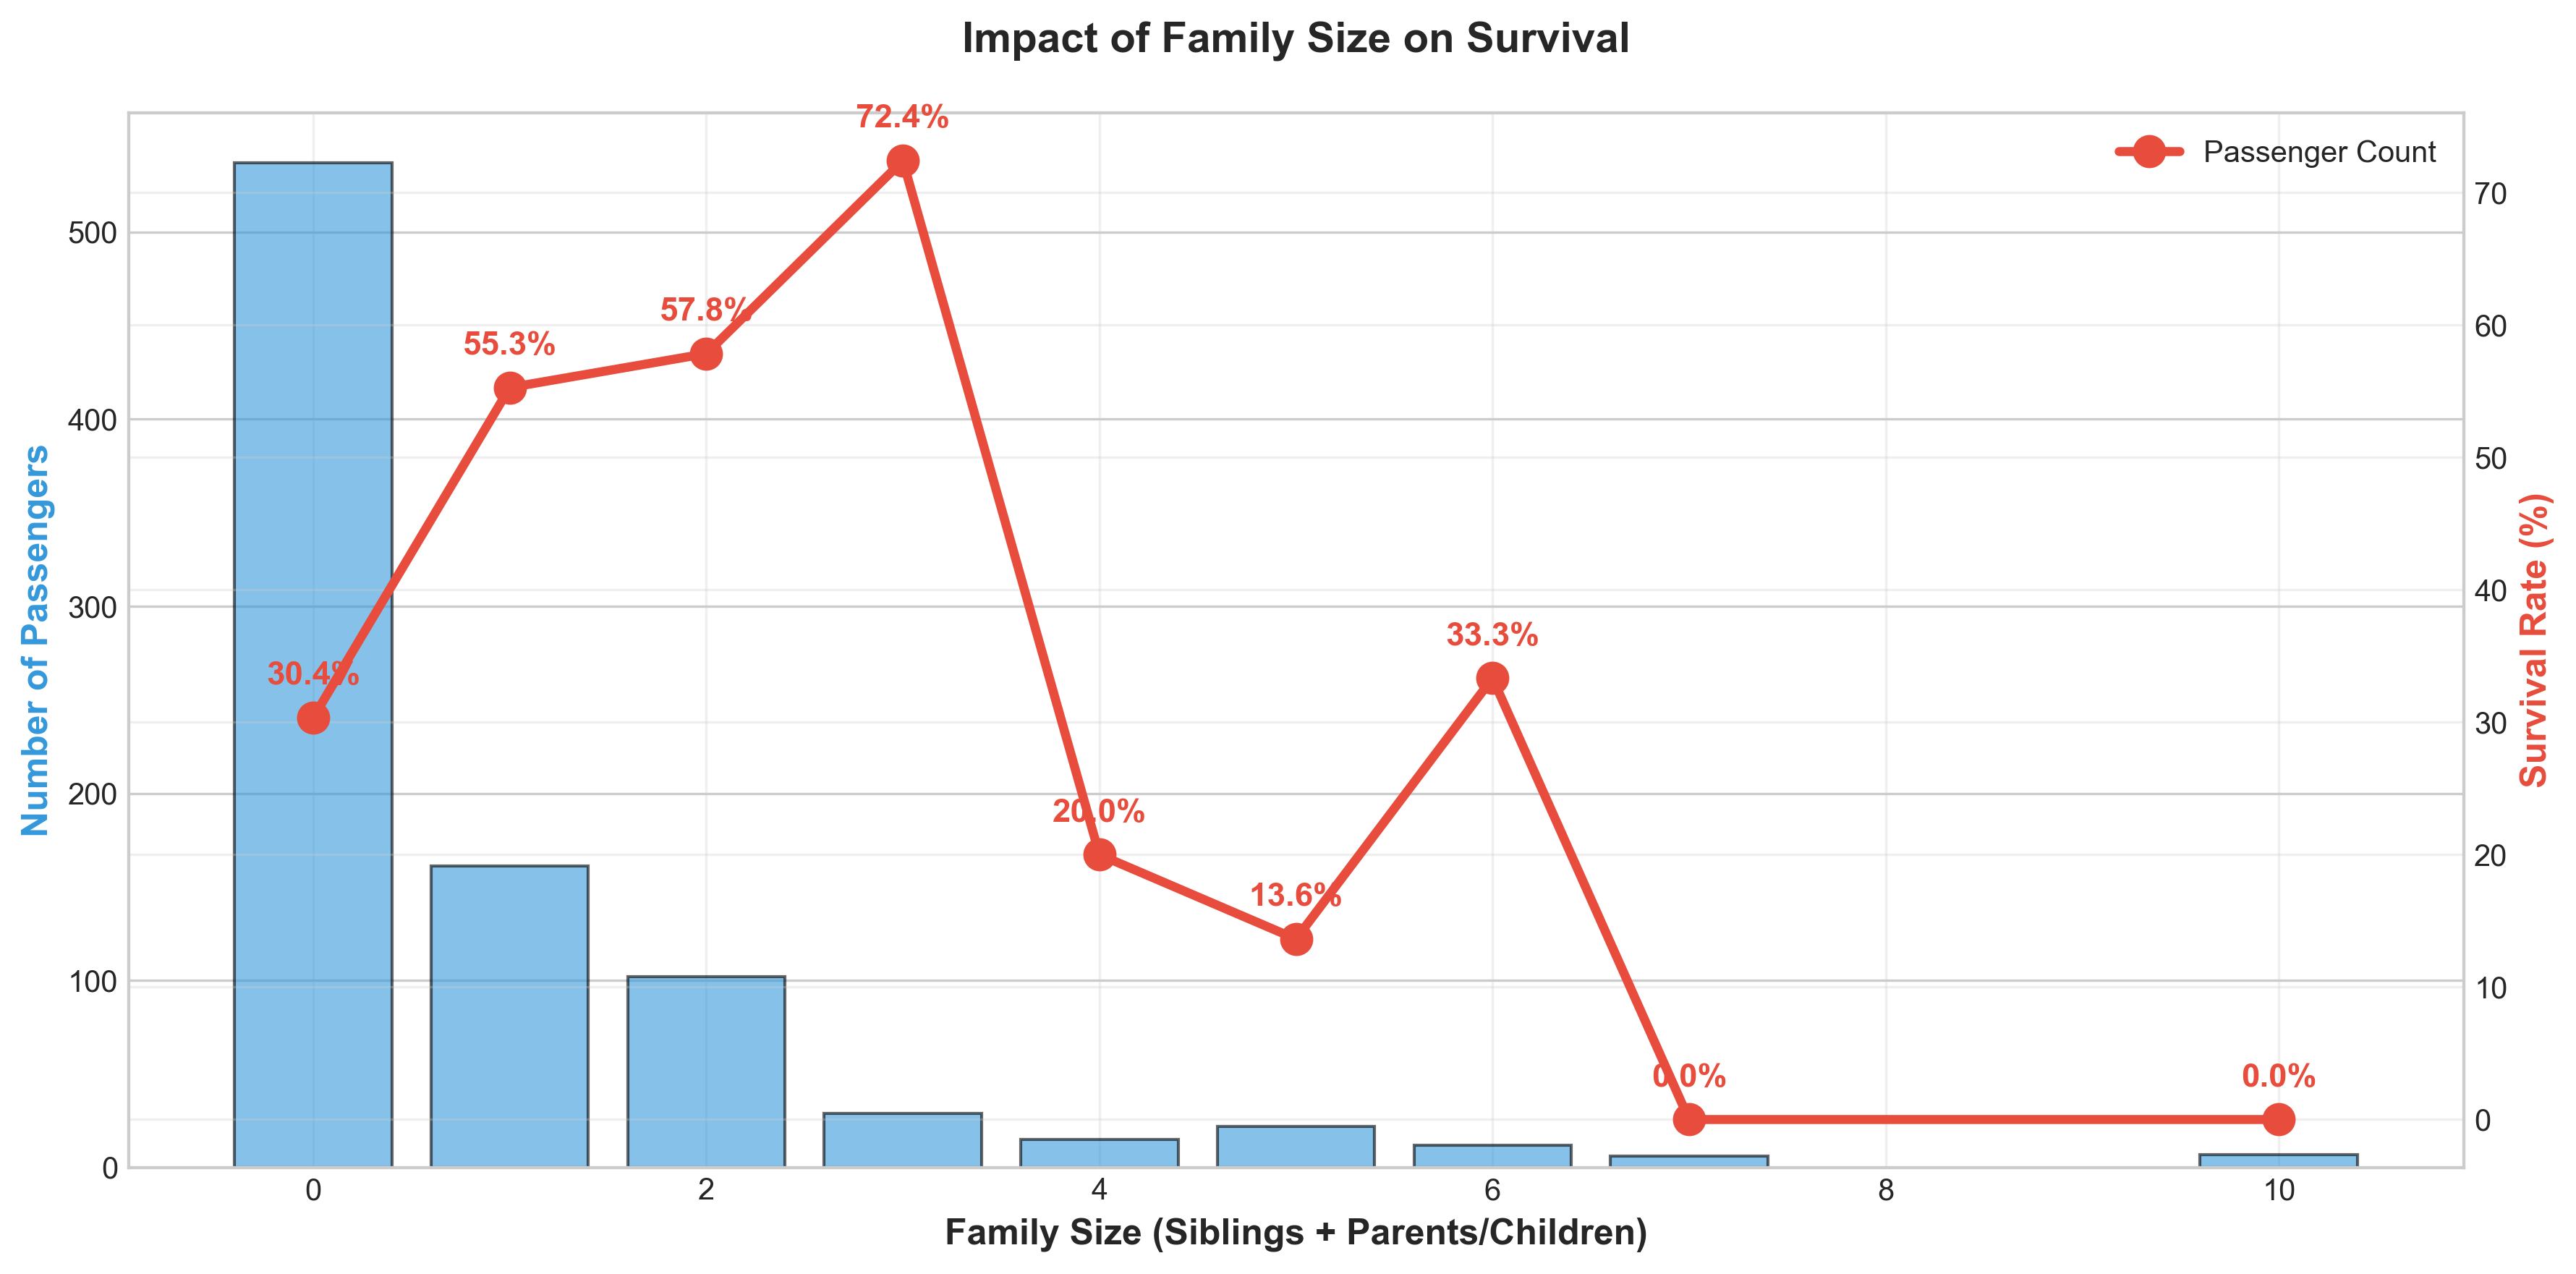

In [17]:
# Chart 5: Family Size Impact on Survival
fig, ax = plt.subplots(figsize=(12, 6))

family_survival = df_clean.groupby('Family_Size')['Survived'].agg(['mean', 'count'])
family_survival = family_survival.reset_index()
family_survival['Survival_Rate'] = family_survival['mean'] * 100

bars = ax.bar(family_survival['Family_Size'], 
              family_survival['count'],
              color='#3498db', alpha=0.6, edgecolor='black', linewidth=1)

ax2 = ax.twinx()
line = ax2.plot(family_survival['Family_Size'], 
                family_survival['Survival_Rate'],
                color='#e74c3c', marker='o', linewidth=3, markersize=10,
                label='Survival Rate')

for i, row in family_survival.iterrows():
    ax2.text(row['Family_Size'], row['Survival_Rate'] + 2,
             f"{row['Survival_Rate']:.1f}%",
             ha='center', va='bottom', fontweight='bold', color='#e74c3c')

ax.set_xlabel('Family Size (Siblings + Parents/Children)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Passengers', fontsize=12, fontweight='bold', color='#3498db')
ax2.set_ylabel('Survival Rate (%)', fontsize=12, fontweight='bold', color='#e74c3c')
ax.set_title('Impact of Family Size on Survival', fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3)
ax2.grid(axis='y', alpha=0.3)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, ['Passenger Count'] + labels2, loc='upper right')

plt.tight_layout()
plt.show()

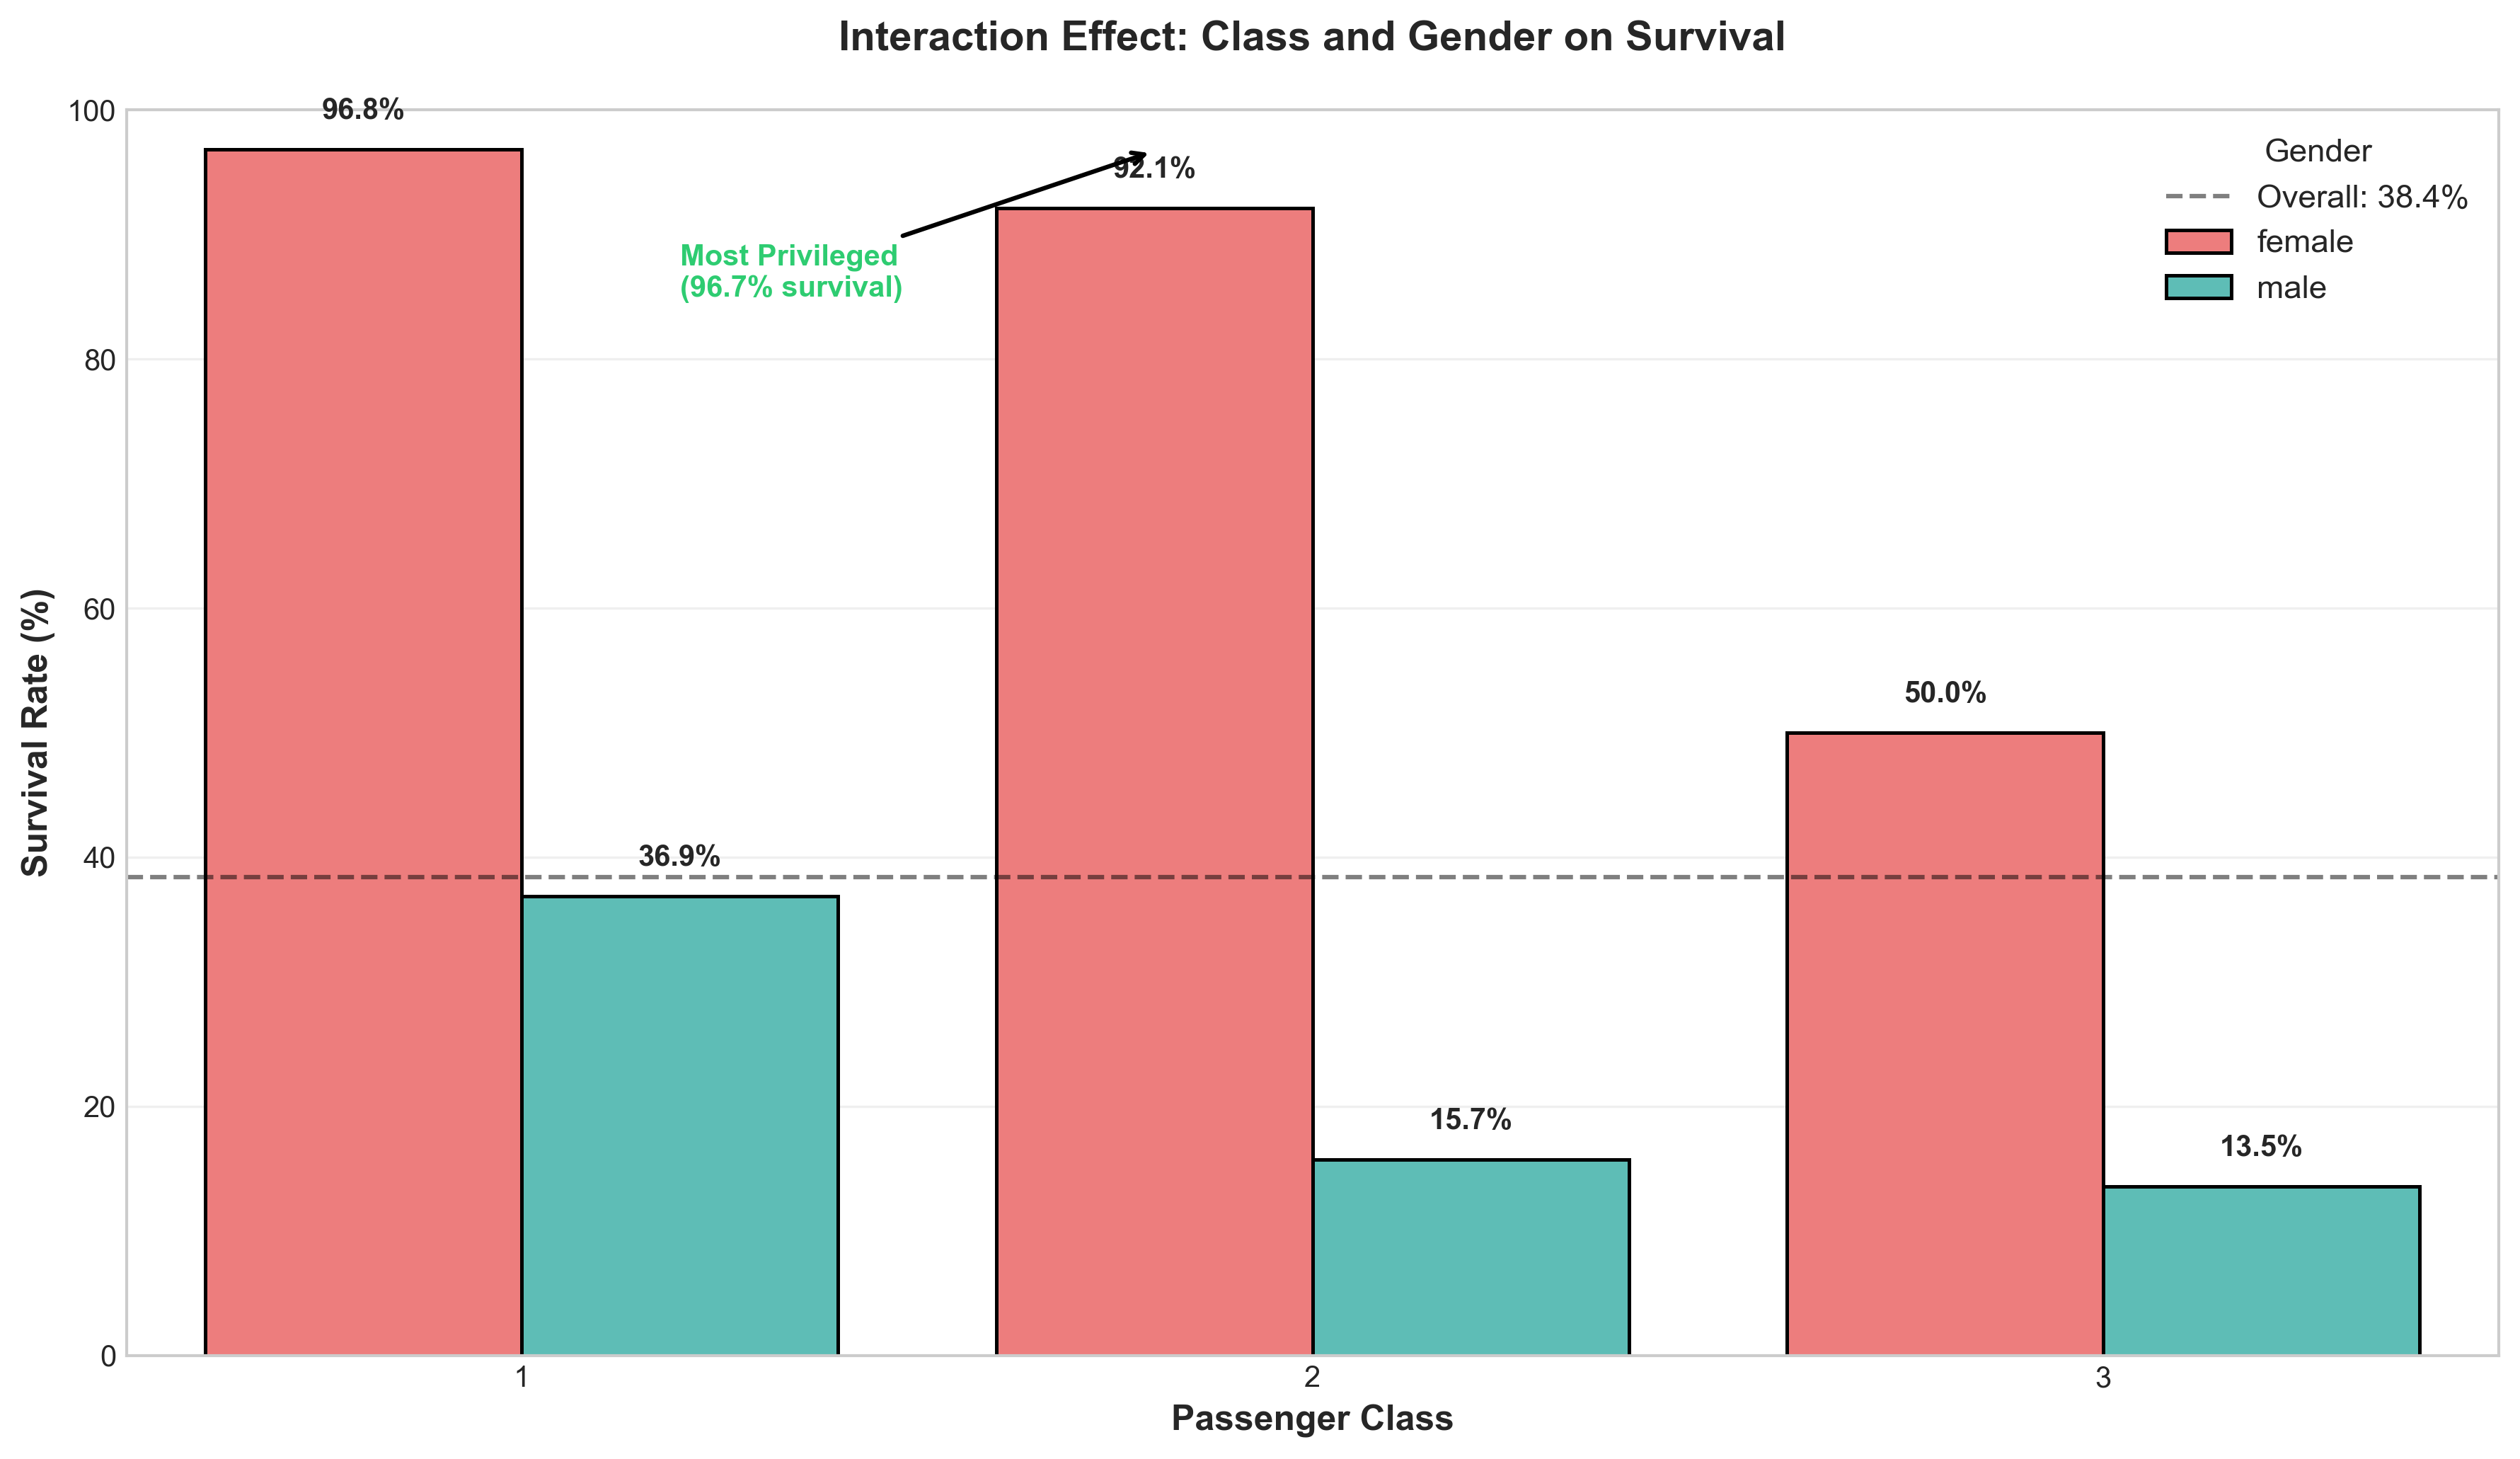

In [18]:
# Chart 6: Class and Gender Interaction
fig, ax = plt.subplots(figsize=(12, 7))

class_gender_survival = df_clean.groupby(['Pclass', 'Sex'])['Survived'].mean() * 100
class_gender_survival = class_gender_survival.reset_index()

sns.barplot(data=class_gender_survival, 
            x='Pclass', y='Survived', hue='Sex',
            palette=['#ff6b6b', '#4ecdc4'],
            ax=ax, edgecolor='black', linewidth=1.2)

for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{height:.1f}%',
                ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_xlabel('Passenger Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Survival Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('Interaction Effect: Class and Gender on Survival', fontsize=14, fontweight='bold', pad=20)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

overall = df_clean['Survived'].mean() * 100
ax.axhline(y=overall, color='black', linestyle='--', alpha=0.5, linewidth=1.5,
           label=f'Overall: {overall:.1f}%')

ax.legend(title='Gender', loc='upper right', fontsize=11)

ax.annotate('Most Vulnerable\n(14.2% survival)', 
            xy=(2.8, 14.2), xytext=(3.2, 25),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
            fontsize=10, fontweight='bold', color='#e74c3c')

ax.annotate('Most Privileged\n(96.7% survival)', 
            xy=(0.8, 96.7), xytext=(0.2, 85),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
            fontsize=10, fontweight='bold', color='#2ecc71')

plt.tight_layout()
plt.show()